In [1]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population, compute_total_population, compute_rur_urb_pop
from imagematerials.util import merge_dims, dataset_to_array


In [2]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [3]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


In [4]:


# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})



In [5]:
print(floorspace_commercial.pint.units)

meter ** 2 / person


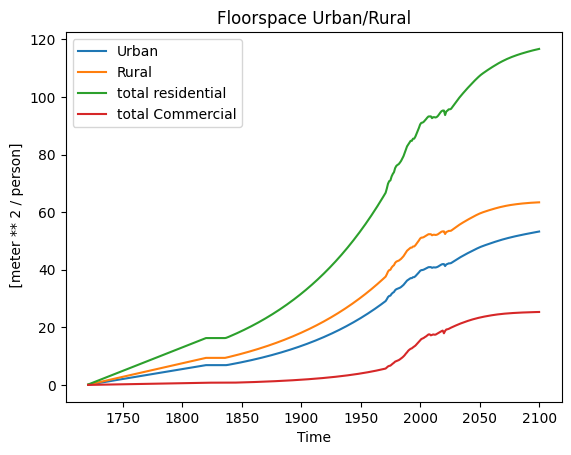

In [6]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sel(Area="Urban", Region = '11').plot(label="Urban")
floorspace_rururb.sel(Area="Rural", Region = '11').plot(label="Rural")
floorspace_rururb.sel(Region = '11').sum(["Area"]).plot(label="total residential")
floorspace_commercial.sel(Region = '11').sum(["Type"]).plot(label="total Commercial")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [7]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

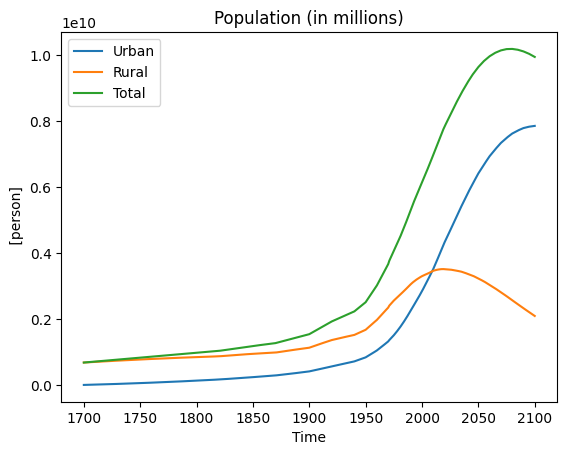

In [8]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [9]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
print('average_m2_capita:', average_m2_capita.pint.units)
housing_type = compute_housing_type(database_directory)



average_m2_capita: meter ** 2 / person


In [12]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb, None)

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials\Lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


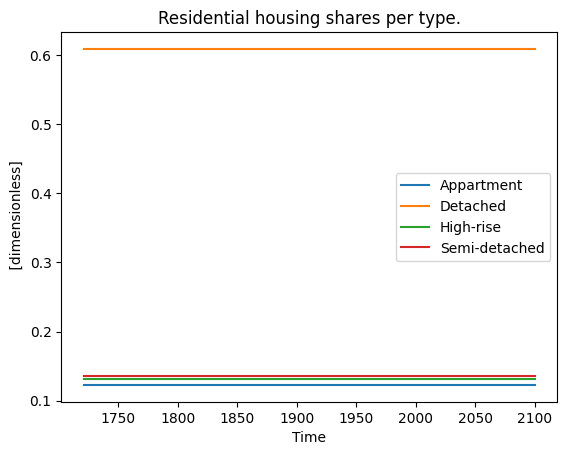

In [13]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

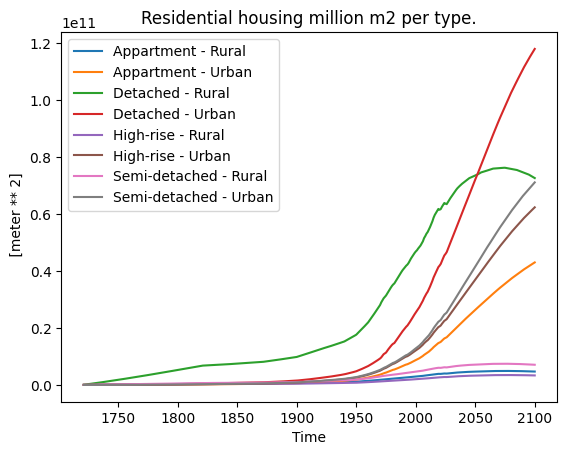

In [14]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [ ]:
floorspace_commercial_total = floorspace_commercial * population.sel({"Area": "Total"})
floorspace = xr.concat((floorspace_residential, floorspace_commercial_total), dim="Type")